# Comparing Clustering Methods for Sequence Analysis: Hierarchical Clustering vs. PAM

This tutorial walks through a classic sequence analysis workflow and compares two widely used clustering methods: **hierarchical clustering** (Ward's method) and **PAM** (Partitioning Around Medoids). Both are applied to the same dissimilarity matrix, allowing us to see how method choice affects the resulting typology.

## About the Dataset

The **pairfam** (Panel Analysis of Intimate Relationships and Family Dynamics) dataset records the **monthly activity status** of **1027 individuals** born in 1971-1973 in Germany, observed over **264 months** (22 years). Each person's trajectory is a sequence of one of eight activity states:

| State | Description |
|-------|-------------|
| 1 | In school / general education |
| 2 | Vocational training / apprenticeship |
| 3 | Higher education / university |
| 4 | Full-time employment |
| 5 | Part-time employment |
| 6 | Parental leave / homemaking |
| 7 | Unemployed |
| 8 | Other (military service, gap year, etc.) |

The dataset also contains 16 background covariates (gender, education, East/West Germany, etc.) that can help interpret cluster differences.

## Research Question

**Do hierarchical clustering and PAM produce similar or different typologies of activity trajectories?** Specifically:
- How do the cluster quality metrics compare?
- Do the two methods identify the same groups, or do they disagree on cluster membership?
- Which method yields more interpretable and internally coherent clusters for this data?

## Workflow

1. Load data and create `SequenceData`
2. Compute a dissimilarity matrix (Optimal Matching)
3. Apply hierarchical clustering (Ward's method)
4. Apply PAM (KMedoids), initialised from hierarchical results
5. Compare the two methods:
   - Cluster size distributions
   - Cross-tabulation of cluster memberships
   - State distribution plots for each method
   - Covariate profiles by cluster
   - Agreement rate after optimal label alignment

## Step 1: Import Libraries and Load Data

In [1]:
# Import Sequenzo and other necessary libraries
from sequenzo import *
from sequenzo.dissimilarity_measures import get_distance_matrix
from sequenzo.clustering.KMedoids import KMedoids
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Prepare Sequence Data

We separate the covariate columns from the 264 monthly activity columns and create a `SequenceData` object.

In [2]:
# Load the pairfam activity dataset
df = pd.read_csv("pairfam_activity_by_month.csv")

print(f"Dataset shape: {df.shape}")
print(f"Number of individuals: {len(df)}")
df.head(3)

Dataset shape: (1027, 281)
Number of individuals: 1027


,id,weight40,sex,doby_gen,dob,ethni,migstatus,yeduc,sat1i4,sat5,...,255,256,257,258,259,260,261,262,263,264
0,111000.0,0.343964,1,1971,855,1,1,11.5,5,7,...,8,8,8,8,8,8,8,8,8,8
1,2931000.0,1.767455,0,1973,881,5,3,10.5,5,5,...,4,4,4,4,4,4,4,4,4,4
2,3491000.0,0.726561,1,1971,857,1,1,18.0,10,-2,...,6,6,6,6,6,6,6,3,3,3


In [3]:
# Identify covariate and time columns
COVARIATE_COLS = ['id', 'weight40', 'sex', 'doby_gen', 'dob', 'ethni',
                  'migstatus', 'yeduc', 'sat1i4', 'sat5', 'sat6',
                  'highschool', 'church', 'biosib', 'stepsib',
                  'east', 'famstructure18']
TIME_COLS = [c for c in df.columns if c not in COVARIATE_COLS]

print(f"Time columns: {len(TIME_COLS)} months")
print(f"Covariates: {len(COVARIATE_COLS) - 1}")  # exclude id

Time columns: 264 months
Covariates: 16


In [4]:
# Define the 8 activity states with labels
STATES = ['school', 'voc_training', 'higher_ed', 'employed_FT',
          'employed_PT', 'parental_leave', 'unemployed', 'other']

# Map integer codes to string labels
state_map = {i+1: s for i, s in enumerate(STATES)}
df_seq = df.copy()
for col in TIME_COLS:
    df_seq[col] = df_seq[col].map(state_map)

# Create SequenceData object
sequence_data = SequenceData(df_seq, time=TIME_COLS, states=STATES, id_col='id')

print(f"Sequences:   {sequence_data.n_sequences}")
print(f"Time points: {len(TIME_COLS)}")
print(f"States:      {sequence_data.alphabet}")


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 1027
[>] Number of time points: 264
[>] Min/Max sequence length: 264 / 264
[>] States: ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']
[>] Labels: ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']
[>] Weights: Not provided
Sequences:   1027
Time points: 264
States:      ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']


## Step 3: Compute Dissimilarity Matrix

Both clustering methods operate on the same dissimilarity matrix. We use **Optimal Matching (OM)** with transition-rate-based substitution costs and automatic indel cost.

In [5]:
# Compute the Optimal Matching dissimilarity matrix
om = get_distance_matrix(
    seqdata=sequence_data,
    method='OM',
    sm='TRATE',
    indel='auto'
)

print(f"Dissimilarity matrix shape: {om.shape}")
print(f"Min distance: {om.values[np.triu_indices_from(om.values, k=1)].min():.2f}")
print(f"Max distance: {om.values[np.triu_indices_from(om.values, k=1)].max():.2f}")
print(f"Mean distance: {om.values[np.triu_indices_from(om.values, k=1)].mean():.2f}")

[>] Processing 1027 sequences with 8 unique states.
[>] Transition-based substitution-cost matrix (TRATE) initiated...
  - Computing transition probabilities for: [school, voc_training, higher_ed, employed_FT, employed_PT, parental_leave, unemployed, other]
[>] generated an indel of type number

[>] Identified 937 unique sequences.
[>] Starting Optimal Matching(OM)...
[>] Computing all pairwise distances...
[>] Computed Successfully.
Dissimilarity matrix shape: (1027, 1027)
Min distance: 0.00
Max distance: 527.65
Mean distance: 257.21


## Step 4: Hierarchical Clustering (Ward's Method)

Ward's method is one of the most common agglomerative clustering approaches in sequence analysis. It minimises the total within-cluster variance at each merge step. We use `Cluster()` from Sequenzo.

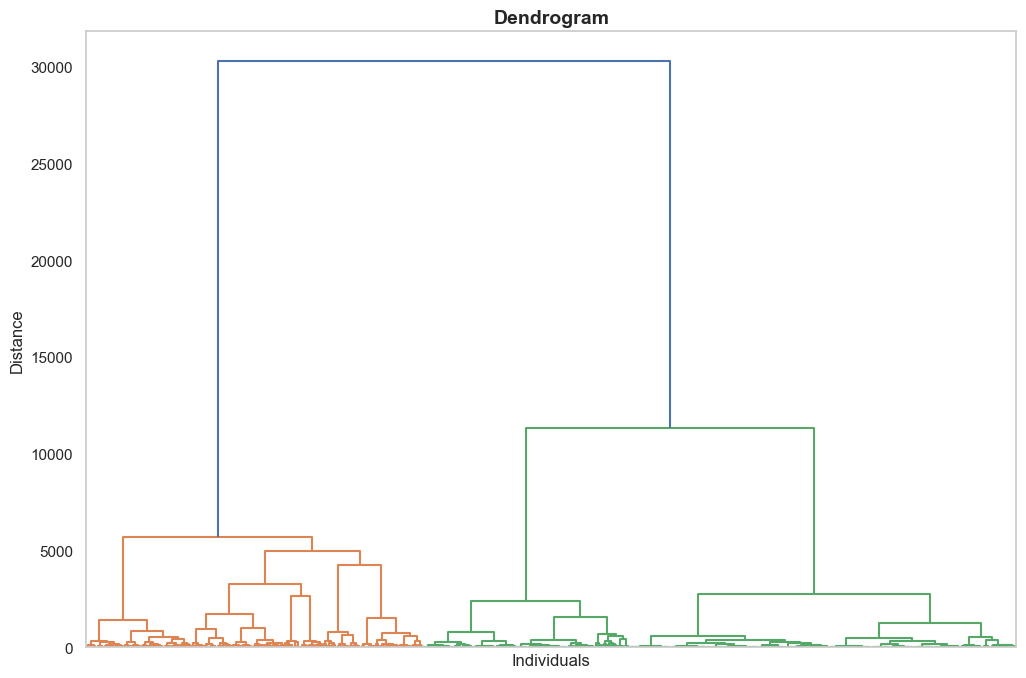

In [6]:
# Hierarchical clustering with Ward's method
hc = Cluster(om, sequence_data.ids, clustering_method='ward_d')

# Plot the dendrogram
hc.plot_dendrogram(xlabel="Individuals", ylabel="Distance")

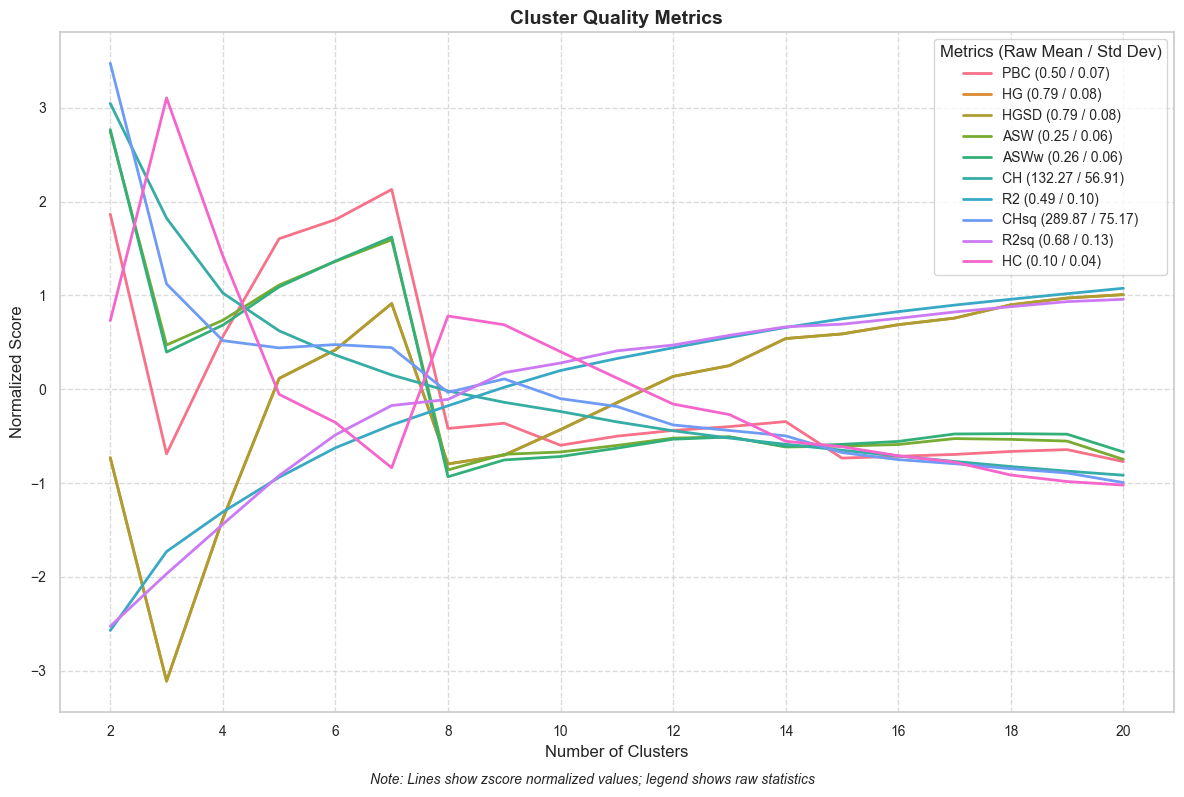


Hierarchical Clustering Quality Scores:
  Metric  Opt. Clusters   Raw Value  Z-Score Norm.
0    PBC            7.0    0.646208       2.128705
1     HG           20.0    0.870324       1.008323
2   HGSD           20.0    0.870317       1.008306
3    ASW            2.0    0.422104       2.746143
4   ASWw            2.0    0.423280       2.766419
5     CH            2.0  305.594541       3.045443
6     R2           20.0    0.601916       1.075878
7   CHsq            2.0  550.976407       3.473643
8   R2sq           20.0    0.802340       0.957992
9     HC            3.0    0.228295       3.104154


In [7]:
# Evaluate clustering quality to decide number of clusters
hc_quality = ClusterQuality(hc)
hc_quality.compute_cluster_quality_scores()
hc_quality.plot_cqi_scores(norm='zscore', save_as=None)

# Print the quality table
hc_summary = hc_quality.get_cqi_table()
print("\nHierarchical Clustering Quality Scores:")
print(hc_summary)

Hierarchical Clustering - Cluster Distribution:
   Cluster  Count  Percentage
0        1    145       14.12
1        2    428       41.67
2        3    228       22.20
3        4    110       10.71
4        5    116       11.30


/Users/yapengwei/Desktop/Sequenzo/sequenzo/clustering/hierarchical_clustering.py:805: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Cluster', y=y_column, data=distribution, palette='pastel')


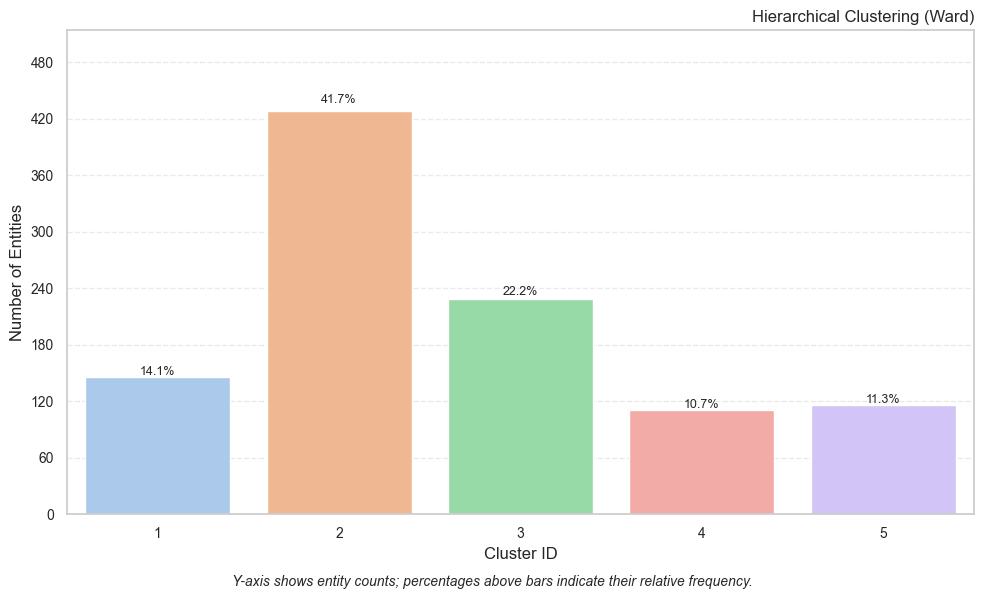

In [8]:
# Extract membership for k=5 clusters
N_CLUSTERS = 5

hc_results = ClusterResults(hc)
hc_membership = hc_results.get_cluster_memberships(num_clusters=N_CLUSTERS)

# Cluster distribution
hc_distribution = hc_results.get_cluster_distribution(num_clusters=N_CLUSTERS)
print("Hierarchical Clustering - Cluster Distribution:")
print(hc_distribution)

hc_results.plot_cluster_distribution(num_clusters=N_CLUSTERS, title="Hierarchical Clustering (Ward)")

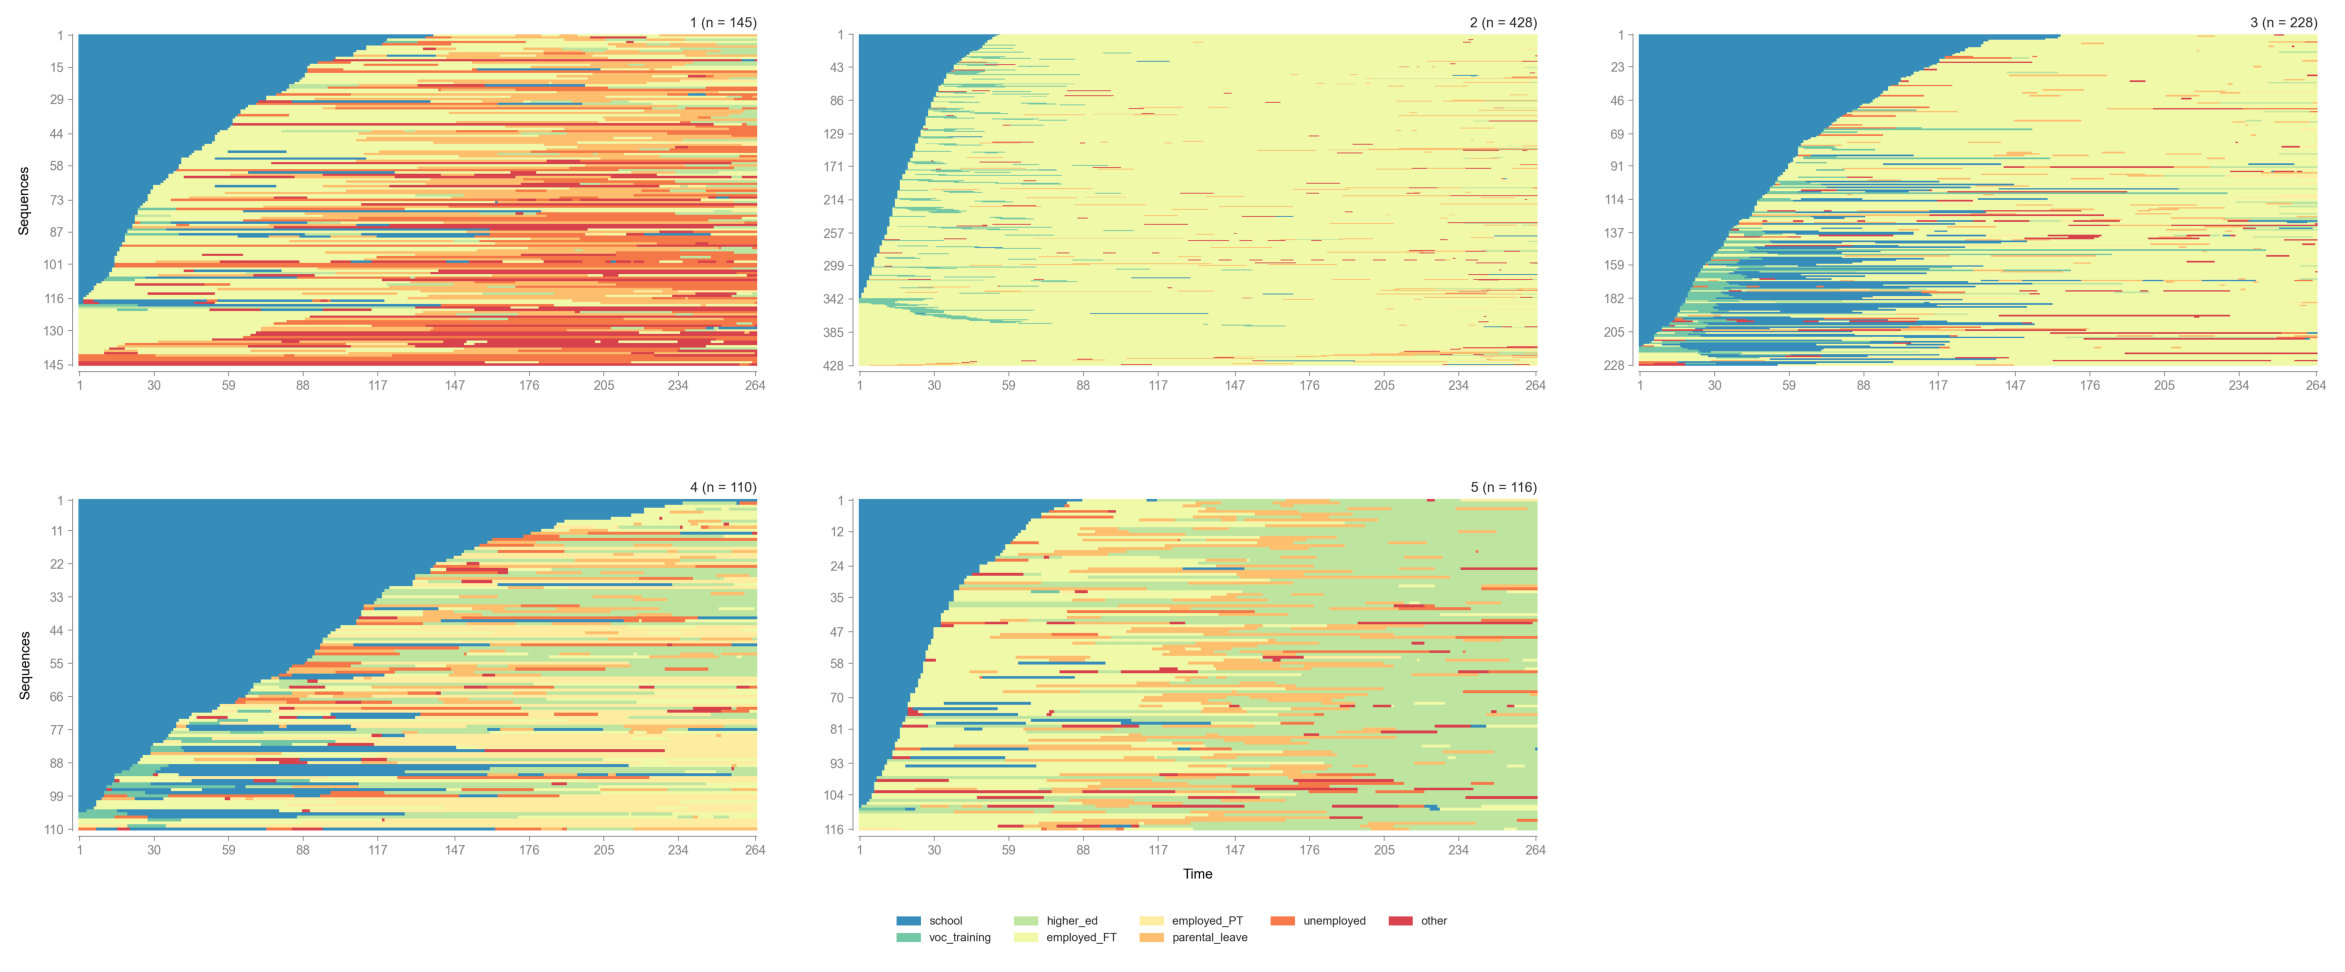

In [9]:
# Sequence index plot by hierarchical cluster
plot_sequence_index(
    seqdata=sequence_data,
    group_dataframe=hc_membership,
    group_column_name="Cluster",
)

## Step 5: PAM Clustering (KMedoids)

PAM (Partitioning Around Medoids) is a partitioning method that selects actual data points as cluster centres (medoids). Unlike hierarchical clustering, PAM directly optimises the within-cluster dissimilarity.

We use the same dissimilarity matrix and the same number of clusters for a fair comparison.

In [10]:
# PAM clustering with the same number of clusters
pam_labels = KMedoids(
    diss=om,
    k=N_CLUSTERS,
    method='PAM',
    npass=10,
    initialclust=hc_membership['Cluster'].values,
    weights=None,
)

# Check cluster label values
print(f"PAM cluster labels: {sorted(np.unique(pam_labels))}")

# Ensure cluster labels are 1-indexed (matching hierarchical output)
if pam_labels.min() == 0:
    pam_labels = pam_labels + 1

# Convert to DataFrame matching the hierarchical membership format
pam_membership = pd.DataFrame({
    'Entity ID': sequence_data.ids,
    'Cluster': pam_labels,
})

# PAM cluster distribution
print("\nPAM Clustering - Cluster Distribution:")
print(pam_membership['Cluster'].value_counts().sort_index())

[>] Starting KMedoids clustering (method: PAM, k=5)...
[>] Computed Successfully.
PAM cluster labels: [np.int32(9), np.int32(228), np.int32(306), np.int32(606), np.int32(807)]

PAM Clustering - Cluster Distribution:
Cluster
9      456
228    116
306    141
606     94
807    220
Name: count, dtype: int64


### Comparing Cluster Quality

Sequenzo's `ClusterQuality` is designed for hierarchical clustering (`Cluster` objects) and evaluates quality across a range of cluster numbers. For PAM, we compute a comparable metric directly: the **average within-cluster dissimilarity** for both methods at the chosen k, using the shared dissimilarity matrix.

In [11]:
# Compute average within-cluster dissimilarity for both methods
# Lower values indicate tighter, more homogeneous clusters

def avg_within_cluster_diss(diss_matrix, labels):
    """Compute average within-cluster dissimilarity for each cluster."""
    diss = diss_matrix.values if hasattr(diss_matrix, 'values') else diss_matrix
    unique_labels = sorted(set(labels))
    results = {}
    total_within = 0
    total_pairs = 0
    for lab in unique_labels:
        idx = np.where(np.array(labels) == lab)[0]
        if len(idx) < 2:
            results[lab] = 0.0
            continue
        within = 0
        n_pairs = 0
        for a in range(len(idx)):
            for b in range(a+1, len(idx)):
                within += diss[idx[a], idx[b]]
                n_pairs += 1
        results[lab] = within / n_pairs
        total_within += within
        total_pairs += n_pairs
    overall = total_within / total_pairs if total_pairs > 0 else 0
    return results, overall

hc_per_cluster, hc_overall = avg_within_cluster_diss(om, hc_membership['Cluster'].values)
pam_per_cluster, pam_overall = avg_within_cluster_diss(om, pam_membership['Cluster'].values)

print("Average Within-Cluster Dissimilarity:")
print("=" * 55)
print(f"{'Cluster':<12} {'Hierarchical':>15} {'PAM':>15}")
print("-" * 55)
for k in sorted(hc_per_cluster.keys()):
    hc_val = hc_per_cluster.get(k, float('nan'))
    pam_val = pam_per_cluster.get(k, float('nan'))
    print(f"{'Cluster '+str(k):<12} {hc_val:15.2f} {pam_val:15.2f}")
print("-" * 55)
print(f"{'Overall':<12} {hc_overall:15.2f} {pam_overall:15.2f}")

if pam_overall < hc_overall:
    print(f"\nPAM achieves lower overall within-cluster dissimilarity ({pam_overall:.2f} vs {hc_overall:.2f}),")
    print("indicating tighter clusters.")
else:
    print(f"\nHierarchical achieves lower overall within-cluster dissimilarity ({hc_overall:.2f} vs {pam_overall:.2f}),")
    print("indicating tighter clusters.")

Average Within-Cluster Dissimilarity:
Cluster         Hierarchical             PAM
-------------------------------------------------------
Cluster 1             296.28             nan
Cluster 2              69.89             nan
Cluster 3             142.01             nan
Cluster 4             293.23             nan
Cluster 5             196.61             nan
-------------------------------------------------------
Overall               115.59          116.97

Hierarchical achieves lower overall within-cluster dissimilarity (115.59 vs 116.97),
indicating tighter clusters.


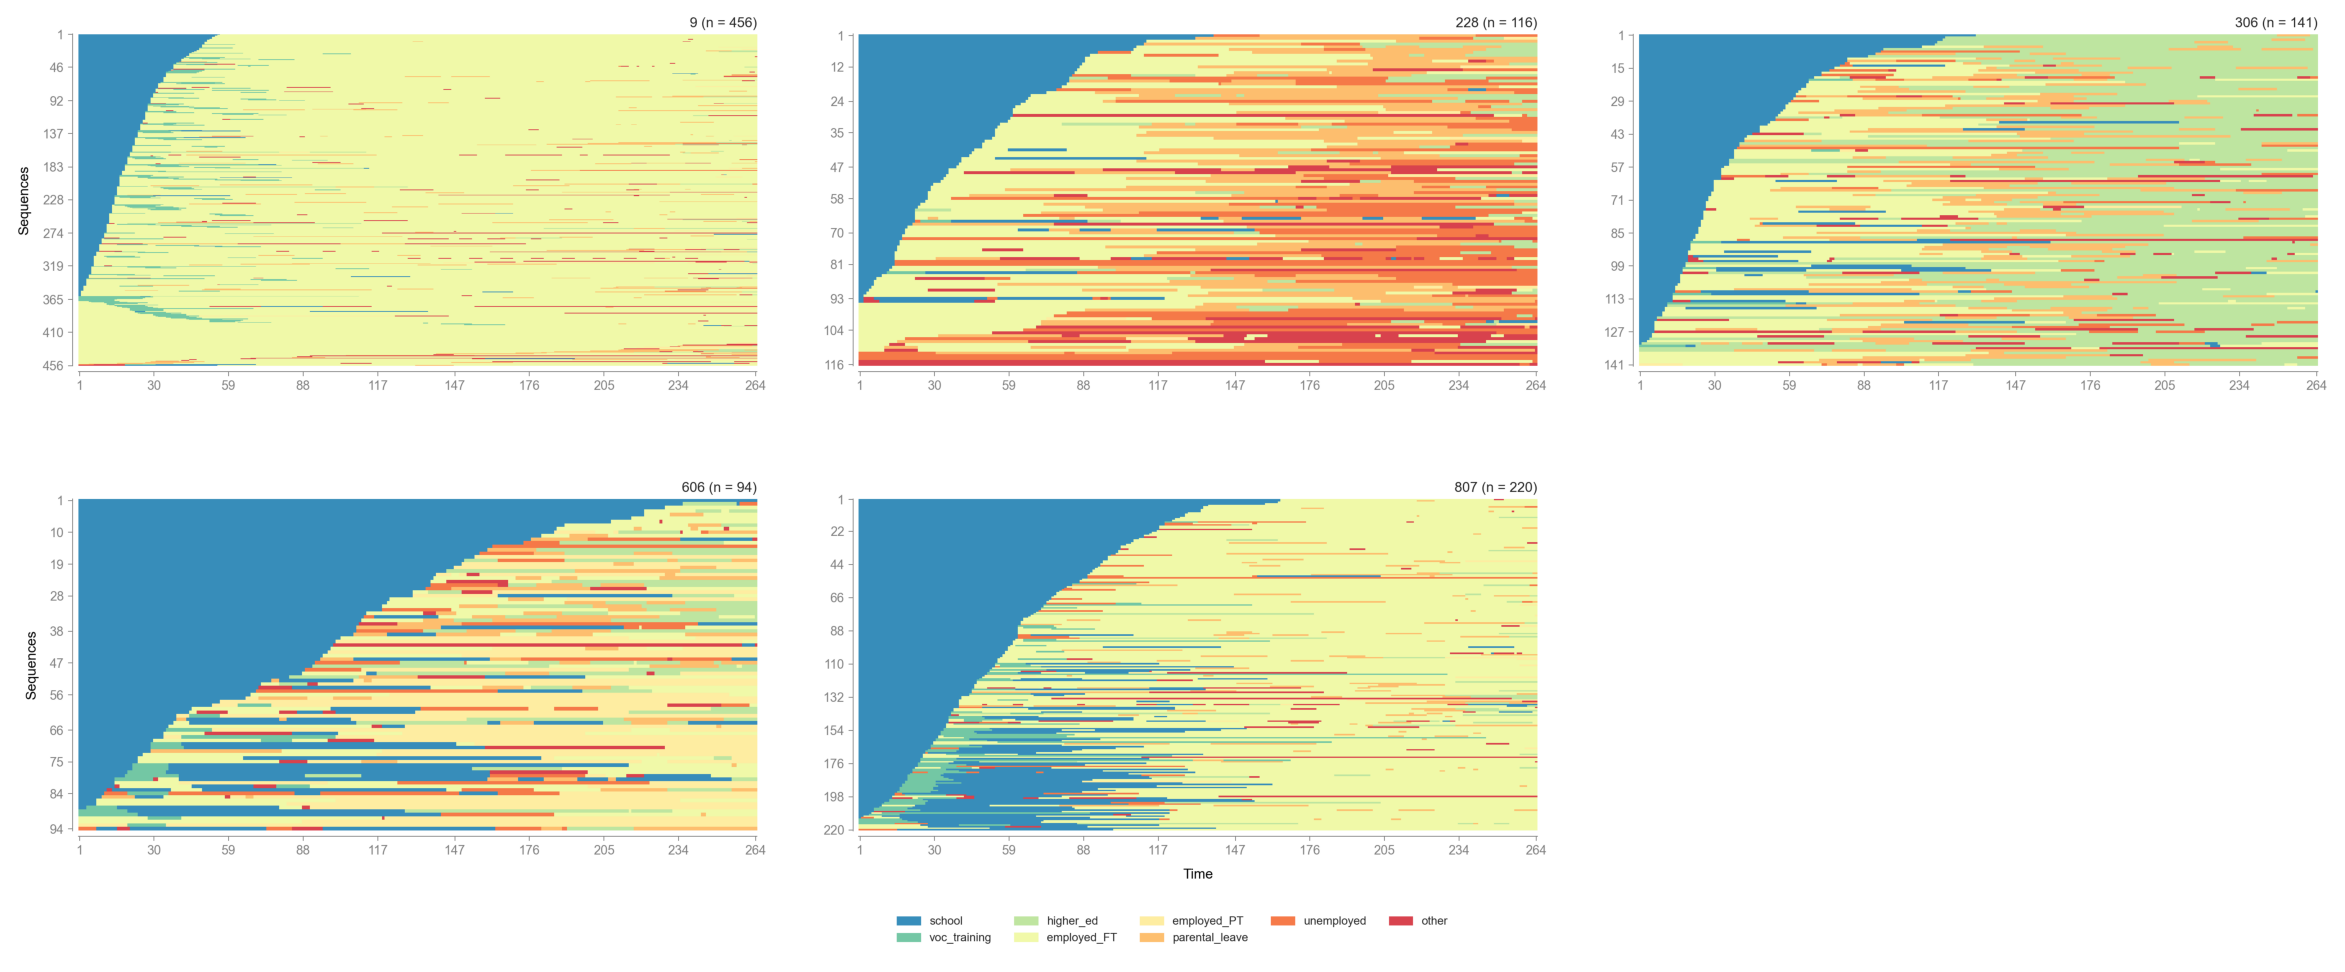

In [12]:
# Sequence index plot by PAM cluster
plot_sequence_index(
    seqdata=sequence_data,
    group_dataframe=pam_membership,
    group_column_name="Cluster",
)

## Step 6: Compare the Two Methods

### 6.1 Cluster Size Distribution

First, we compare how the two methods distribute individuals across clusters.

Cluster Size Comparison:
           Hierarchical (Ward)  PAM
Cluster 1                  145  456
Cluster 2                  428  116
Cluster 3                  228  141
Cluster 4                  110   94
Cluster 5                  116  220


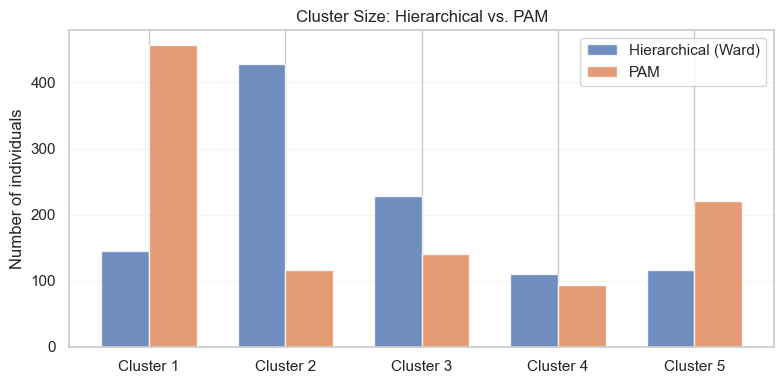

In [13]:
# Side-by-side cluster size comparison
hc_counts = hc_membership['Cluster'].value_counts().sort_index()
pam_counts = pam_membership['Cluster'].value_counts().sort_index()

comparison_df = pd.DataFrame({
    'Hierarchical (Ward)': hc_counts.values,
    'PAM': pam_counts.values,
}, index=[f'Cluster {i}' for i in hc_counts.index])

print("Cluster Size Comparison:")
print(comparison_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(N_CLUSTERS)
width = 0.35
ax.bar(x - width/2, comparison_df['Hierarchical (Ward)'], width, label='Hierarchical (Ward)', alpha=0.8)
ax.bar(x + width/2, comparison_df['PAM'], width, label='PAM', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylabel('Number of individuals')
ax.set_title('Cluster Size: Hierarchical vs. PAM')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 6.2 Cross-Tabulation: Do they agree on cluster membership?

A cross-tabulation shows how individuals assigned to one method's clusters are distributed across the other method's clusters. Strong diagonal dominance would indicate agreement.

Cross-tabulation (rows = Hierarchical, columns = PAM):
PAM           9    228  306  606  807
Hierarchical                         
1               6  107    4   14   14
2             423    0    0    0    5
3              25    3    3    2  195
4               1    5   21   77    6
5               1    1  113    1    0


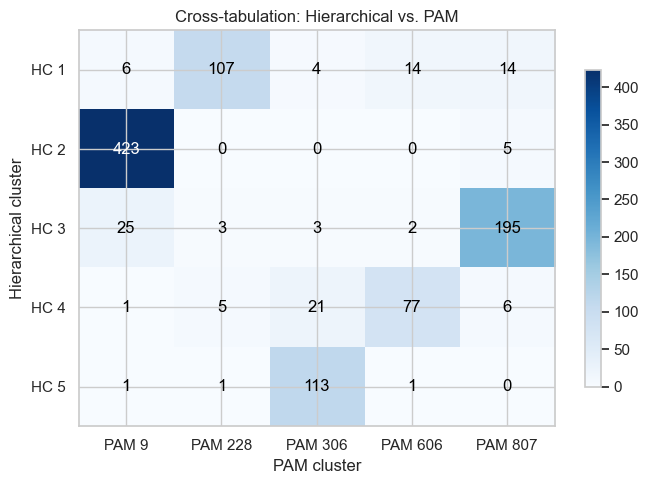

In [14]:
# Cross-tabulation of the two clusterings
cross_tab = pd.crosstab(
    hc_membership['Cluster'].values,
    pam_membership['Cluster'].values,
    rownames=['Hierarchical'],
    colnames=['PAM']
)
print("Cross-tabulation (rows = Hierarchical, columns = PAM):")
print(cross_tab)

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cross_tab.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(N_CLUSTERS))
ax.set_yticks(range(N_CLUSTERS))
ax.set_xticklabels([f'PAM {i}' for i in cross_tab.columns])
ax.set_yticklabels([f'HC {i}' for i in cross_tab.index])
ax.set_xlabel('PAM cluster')
ax.set_ylabel('Hierarchical cluster')
ax.set_title('Cross-tabulation: Hierarchical vs. PAM')

for i in range(cross_tab.shape[0]):
    for j in range(cross_tab.shape[1]):
        color = 'white' if cross_tab.values[i, j] > cross_tab.values.max() / 2 else 'black'
        ax.text(j, i, str(cross_tab.values[i, j]), ha='center', va='center', color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### 6.3 State Distribution by Cluster

We compare the state distribution plots for each method's clusters to see whether the resulting groups have a clear substantive interpretation.

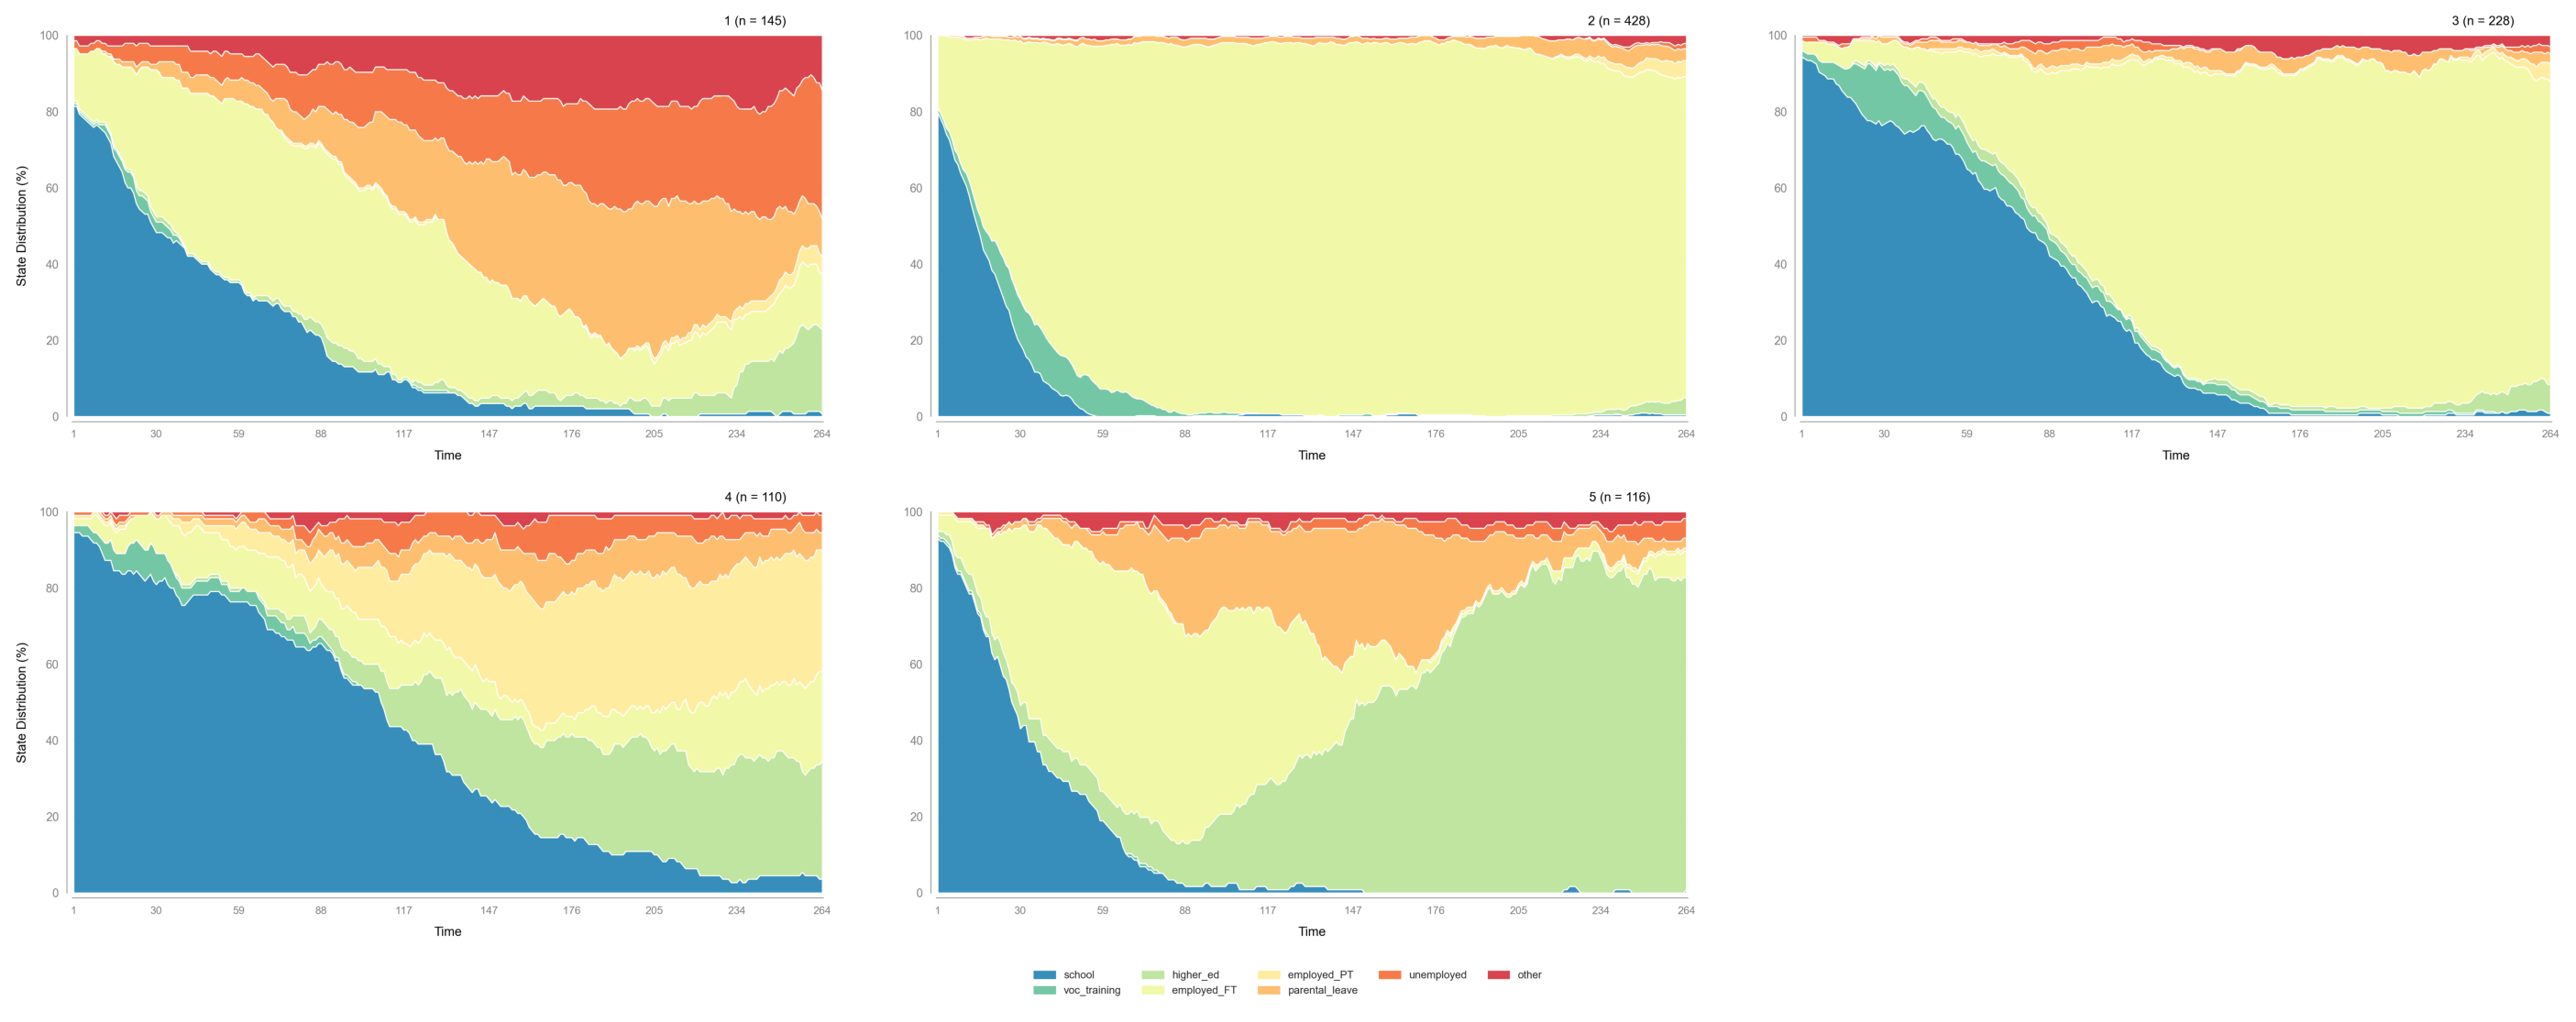

In [15]:
# State distribution plot for hierarchical clustering
plot_state_distribution(
    seqdata=sequence_data,
    group_dataframe=hc_membership,
    group_column_name="Cluster",
)

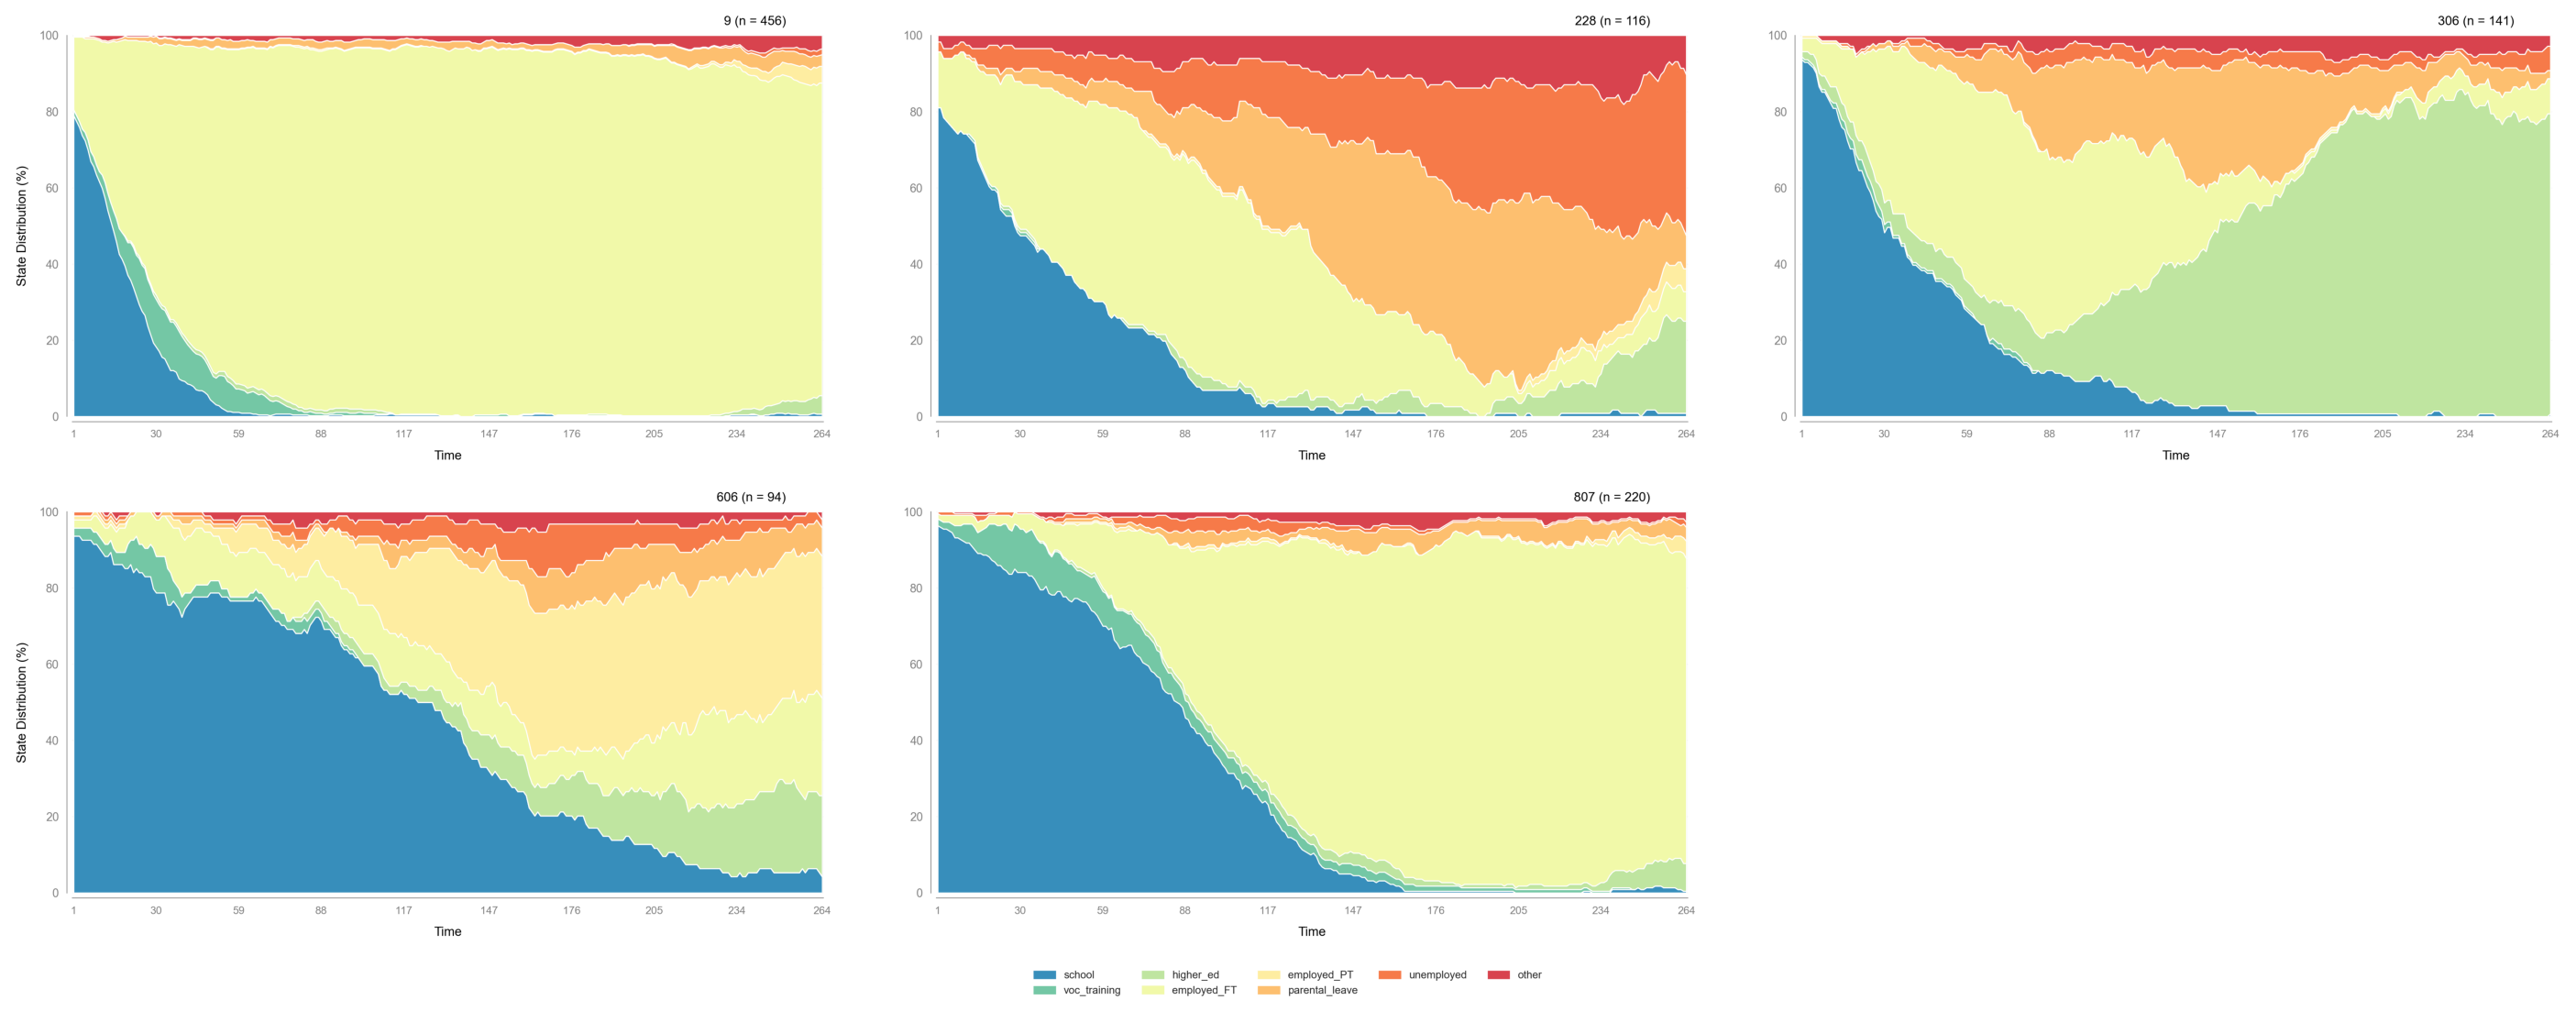

In [16]:
# State distribution plot for PAM
plot_state_distribution(
    seqdata=sequence_data,
    group_dataframe=pam_membership,
    group_column_name="Cluster",
)

### 6.4 Cluster Profiles by Covariates

We compare whether the two methods produce clusters with different socio-demographic compositions.

In [17]:
# Add both cluster memberships to the original dataframe
df_compare = df.copy()
df_compare['hc_cluster'] = hc_membership['Cluster'].values
df_compare['pam_cluster'] = pam_membership['Cluster'].values

# Compare key covariates across clusters
covariates_to_check = ['sex', 'yeduc', 'east', 'highschool']

print("Hierarchical Clustering - Mean covariates by cluster:")
print("=" * 55)
print(df_compare.groupby('hc_cluster')[covariates_to_check].mean().round(3))

print("\nPAM Clustering - Mean covariates by cluster:")
print("=" * 55)
print(df_compare.groupby('pam_cluster')[covariates_to_check].mean().round(3))

Hierarchical Clustering - Mean covariates by cluster:
              sex   yeduc   east  highschool
hc_cluster                                  
1           0.876  13.579  0.283       0.441
2           0.304  12.166  0.435       0.157
3           0.360  15.732  0.395       0.746
4           0.627  15.941  0.409       0.745
5           0.974  13.185  0.310       0.362

PAM Clustering - Mean covariates by cluster:
               sex   yeduc   east  highschool
pam_cluster                                  
9            0.316  12.230  0.450       0.169
228          0.948  13.397  0.233       0.397
306          0.950  13.532  0.312       0.426
606          0.585  16.021  0.436       0.755
807          0.355  15.914  0.368       0.777


### 6.5 Agreement Rate

A simple measure of how much the two methods agree: what proportion of individuals are placed in the same cluster (after aligning cluster labels)?

In [18]:
# Compute agreement using the best one-to-one mapping between cluster labels
from itertools import permutations

hc_labels = hc_membership['Cluster'].values
pam_labels = pam_membership['Cluster'].values

hc_unique = sorted(set(hc_labels))
pam_unique = sorted(set(pam_labels))

print(f"HC labels:  {hc_unique}")
print(f"PAM labels: {pam_unique}")

# Try all permutations: map each PAM label to an HC label
best_agreement = 0
best_mapping = None

for perm in permutations(hc_unique):
    mapping = dict(zip(pam_unique, perm))
    remapped = np.array([mapping[l] for l in pam_labels])
    agreement = np.mean(hc_labels == remapped)
    if agreement > best_agreement:
        best_agreement = agreement
        best_mapping = mapping

print(f"\nBest agreement rate: {best_agreement:.1%}")
print(f"Cluster mapping (PAM -> HC): {best_mapping}")
print(f"\nThis means {best_agreement:.1%} of individuals are placed in the "
      f"same cluster by both methods (after label alignment).")

HC labels:  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
PAM labels: [np.int32(9), np.int32(228), np.int32(306), np.int32(606), np.int32(807)]

Best agreement rate: 89.1%
Cluster mapping (PAM -> HC): {np.int32(9): np.int32(2), np.int32(228): np.int32(1), np.int32(306): np.int32(5), np.int32(606): np.int32(4), np.int32(807): np.int32(3)}

This means 89.1% of individuals are placed in the same cluster by both methods (after label alignment).


## Summary

In this tutorial, we applied two clustering methods to the **pairfam** activity trajectory dataset (1027 individuals, 264 months, 8 activity states) and compared their results.

### Key differences between the methods

| Aspect | Hierarchical (Ward) | PAM (KMedoids)                                                                                                      |
|--------|--------------------|---------------------------------------------------------------------------------------------------------------------|
| Approach | Agglomerative: build a tree, cut at desired k | Partitioning: directly optimise k medoids                                                                           |
| Cluster centres | Virtual (not real data points) | Real data points (medoids)                                                                                          |
| Sensitivity to outliers | More sensitive (chain-like merges) | More robust (medoids are actual sequences)                                                                          |
| Deterministic? | Yes | Depends on initialisation (use `npass` for stability)                                                               |
| Dendrogram | Yes (helps explore different k) | No                                                                                                                  |
| Initialisation | Not needed | Critical. Random initialisation may lead to degenerate solutions; using HC results as `initialclust` is recommended |

### What we found

The two methods produced **highly consistent** results, with an **89.1% agreement rate** after optimal label alignment. The cross-tabulation showed strong diagonal dominance, confirming that both methods largely agree on which individuals belong together.

The five trajectory types identified by both methods have clear substantive profiles visible in the state distribution plots and supported by covariate differences (gender, education, East/West Germany). The small disagreements (about 11% of individuals) occur at cluster boundaries and reflect the different optimisation objectives of the two methods: Ward minimises within-cluster variance, while PAM minimises distance to medoids.

One practical lesson from this tutorial: **PAM is sensitive to initialisation**. Without a good starting point, PAM can produce degenerate solutions where nearly all individuals are assigned to a single cluster. Using the hierarchical clustering result as `initialclust` resolved this issue and produced meaningful clusters.

### Workflow recap

| Step | What we did | Key function |
|------|-------------|-------------|
| Data preparation | Loaded pairfam, created `SequenceData` | `SequenceData()` |
| Dissimilarity | Optimal Matching with TRATE substitution costs | `get_distance_matrix()` |
| Hierarchical clustering | Ward's method + dendrogram + quality scores | `Cluster()`, `ClusterQuality()` |
| PAM clustering | PAM with HC-initialised medoids, 10 passes | `KMedoids(initialclust=...)` |
| Quality comparison | Average within-cluster dissimilarity for both methods | numpy |
| Comparison | Size, cross-tab, state distributions, covariates, agreement | `plot_sequence_index()`, `plot_state_distribution()` |

---
Last Updated: March 2026

Author: Yapeng Wei

Maintainer: Sequenzo Development Team